# **ETTh1: ARIMA Univariate Forecasting of OT**
---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#!pip install pmdarima                  # only for the first run in Google Colab, if applicable
from pmdarima import auto_arima

----
## **MODEL DEFINITION**
----

In [2]:
# Hyperparameter definition w/o Optuna tuning
context_length  = 96       # [hours]
forecast_length = 16       # [hours]

----
## **DATA PIPELINE**
----

### **Import**

In [3]:
# Import full data set from original source
url =  "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

data_ETTh1 = pd.read_csv(url, sep = ",")
data_ETTh1.set_index('date', inplace=True)

### **Splitting into Training/Validation/Test Sets**

In [4]:
# Number of rows in the source ETTh1 data set
timesteps_source = data_ETTh1.shape[0]     # hours in the full length dataset (rows in the original data frame)
print("Timesteps in the source dataset: ", timesteps_source, "hours")

# Splitting into training, validation, and test splits
hours_per_month = 30 * 24           # hours

training_length   = 12 * hours_per_month         # 12 months
validation_length = 4 * hours_per_month          # 4 months
test_length       = 4 * hours_per_month          # 4 months   

# Create validation and test splits
validation_split  = data_ETTh1.iloc[training_length:(training_length + validation_length)]
test_split        = data_ETTh1.iloc[(training_length + validation_length):(training_length + validation_length + test_length)]

Timesteps in the source dataset:  17420 hours


----
## **Fitting ARIMA**
----

In [5]:
# Fitting ARIMA to the context windows at the end of the validation split == first testing inputs, OT signal only
x_test = validation_split.iloc[-context_length: ]["OT"]
periodicity = 24    #  hours, only considering the main signal

model = auto_arima(
    x_test,
    seasonal=True,
    m = periodicity,
    stepwise=True,
    suppress_warnings=True
)

----
## **Model Testing**
----

### **Prediction & Metrics**

In [6]:
# Ground truth values extracted from the test split
y_target = test_split.iloc[:forecast_length]["OT"]            

# Generating prediction with the fitted ARIMA model
y_prediction = model.predict(n_periods = forecast_length)

In [7]:
# Metrics
test_mse = mean_squared_error(y_target, y_prediction)
test_mae = mean_absolute_error(y_target, y_prediction)

print(f"\nTest MSE: {test_mse:.8f}")
print(f"Test MAE: {test_mae:.8f}")


Test MSE: 0.59953914
Test MAE: 0.55790512


### **Plotting**

In [8]:
# Create time axis, use the input and prediction window
time = np.arange(-context_length,forecast_length, 1)

print(time.shape)   # should be context + forecast = 192 

(112,)


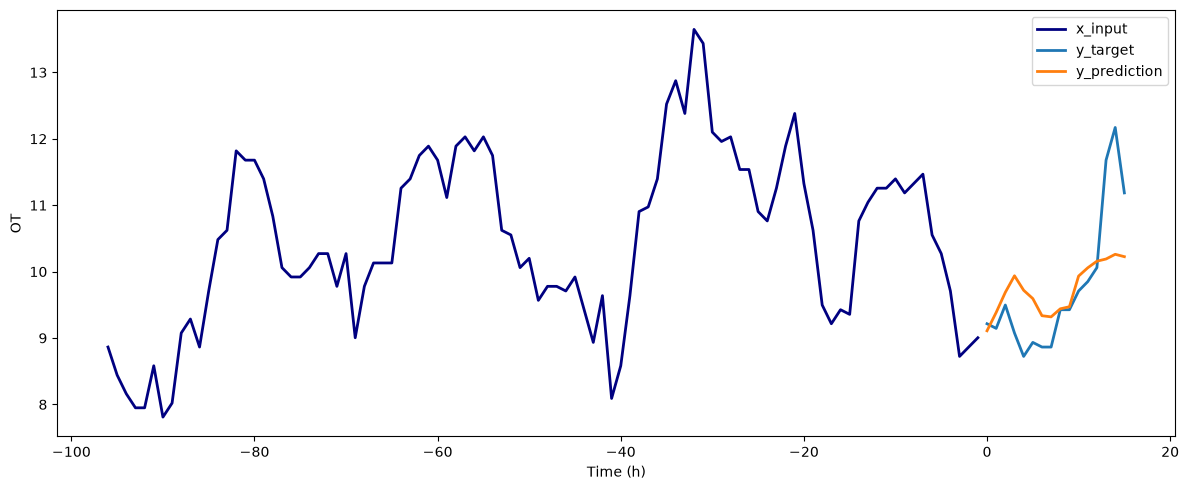

In [9]:
### Plot the results
plt.figure(figsize=(12, 5))

# Plot inputs
plt.plot(
    time[:context_length],
    x_test,
    linewidth=2,
    label="x_input",
    color="navy",
)

# Plot targets
plt.plot(
    time[context_length:(context_length+forecast_length)],
    y_target,
    linewidth=2,
    label="y_target",
    color="tab:blue",
)

# Plot prediction
plt.plot(
    time[context_length:(context_length+forecast_length)],
    y_prediction,
    linewidth=2,
    label="y_prediction",
    color="tab:orange",
)


plt.xlabel("Time (h)")
plt.ylabel("OT")

plt.legend()
plt.tight_layout()
plt.show()